# MindSight: AI-Powered Mental Health Risk Detection Through Conversational Analytics
## Phase 3: Deep Sequential Modeling with Bidirectional LSTM & Self-Attention

---

### Why Sequential Deep Learning for Conversational Analytics?
While classical Bag-of-Words and TF-IDF models treat text as an unordered bag of tokens, conversational distress narratives exhibit **temporal dependencies**, **narrative shifts**, and **negation scopes** (e.g., *"I used to be happy, but now I don't feel like waking up"*).

In this phase, we implement a **Bidirectional Long Short-Term Memory (BiLSTM)** network with a **Self-Attention Pooling Mechanism**:
- **Bidirectional Context**: Simultaneously processes forward (past-to-future) and backward (future-to-past) word sequences.
- **Self-Attention Pooling**: Learns token-level attention weights $\alpha_t$ to focus dynamically on high-salience emotional markers rather than taking a simple static average.
- **Global Max Pooling Concatenation**: Captures sharp, acute distress cues that appear anywhere in the discourse.

> **⚠️ Scope Limitation & Ethical Foundation**:
> **MindSight is strictly an AI-assisted screening and triage aid, NOT a clinical diagnostic tool.**

In [1]:
import json
import os
import sys
from pathlib import Path

# Resolve workspace root
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

from src.features.tokenizer import TextTokenizer, create_dataloaders
from src.models.bilstm import MentalHealthBiLSTM

# Visualization Styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"font.sans-serif": "DejaVu Sans", "font.size": 11, "figure.dpi": 120})

# Output directories
MODELS_DIR = BASE_DIR / "models"
FIGURES_DIR = BASE_DIR / "reports" / "figures"
PROCESSED_DIR = BASE_DIR / "data" / "processed"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch Version: {torch.__version__} | Active Device: {device}")

PyTorch Version: 2.13.0+cpu | Active Device: cpu


---  
## 1. Load Processed Data & Build Sequence Vocabulary
We load `dreaddit_train.csv` and `dreaddit_test.csv` and fit a vocabulary tokenizer with special `<pad>` and `<unk>` tokens (`max_seq_len=160`).

In [2]:
df_train = pd.read_csv(PROCESSED_DIR / "dreaddit_train.csv")
df_val = pd.read_csv(PROCESSED_DIR / "dreaddit_test.csv")

print(f"Training set:   {len(df_train):,} posts")
print(f"Validation set: {len(df_val):,} posts")

# Build and save vocabulary
tokenizer = TextTokenizer(max_vocab_size=12000, min_freq=2, max_seq_len=160)
tokenizer.fit(df_train["text"])
tokenizer.save_vocab(MODELS_DIR / "bilstm_vocab.json")

# Sample sequence encoding check
sample_text = df_train["text"].iloc[0]
encoded_seq, orig_len = tokenizer.encode(sample_text)
print(f"\nSample Text Preview: {sample_text[:120]}...")
print(f"Encoded Vector Length: {len(encoded_seq)} | Unpadded Length: {orig_len}")
print(f"First 10 token indices: {encoded_seq[:10]}")

Training set:   2,838 posts
Validation set: 715 posts
Vocabulary successfully built: 6,329 unique tokens
Saved vocabulary -> d:\MindSight\models\bilstm_vocab.json

Sample Text Preview: He said he had not felt that way before, suggeted I go rest and so ..TRIGGER AHEAD IF YOUI'RE A HYPOCONDRIAC LIKE ME: i ...
Encoded Vector Length: 160 | Unpadded Length: 117
First 10 token indices: [17, 128, 17, 46, 31, 196, 10, 127, 133, 1]


---  
## 2. Initialize PyTorch DataLoaders
Convert tabular text entries into batched PyTorch tensors.

In [3]:
batch_size = 32
train_loader, val_loader = create_dataloaders(
    df_train,
    df_val,
    tokenizer,
    batch_size=batch_size,
)

sample_batch = next(iter(train_loader))
print(f"Batch Input Shape:  {sample_batch['input_ids'].shape}")
print(f"Batch Labels Shape: {sample_batch['label'].shape}")

Batch Input Shape:  torch.Size([32, 160])
Batch Labels Shape: torch.Size([32])


---  
## 3. Instantiate BiLSTM + Attention Neural Network Architecture

In [4]:
torch.manual_seed(42)
np.random.seed(42)

model = MentalHealthBiLSTM(
    vocab_size=tokenizer.vocab_size,
    embedding_dim=128,
    hidden_dim=128,
    num_layers=2,
    dropout=0.35,
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {total_params:,}")
print(model)

Total Trainable Parameters: 1,576,961
MentalHealthBiLSTM(
  (embedding): Embedding(6329, 128, padding_idx=0)
  (embed_dropout): Dropout(p=0.35, inplace=False)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.35, bidirectional=True)
  (attention): AttentionPooling(
    (projection): Sequential(
      (0): Linear(in_features=256, out_features=128, bias=True)
      (1): Tanh()
      (2): Linear(in_features=128, out_features=1, bias=False)
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=512, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.35, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
    (6): ReLU()
    (7): Dropout(p=0.35, inplace=False)
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)


---  
## 4. Model Training Loop with Early Stopping & LR Scheduling

In [5]:
criterion = nn.BCEWithLogitsLoss()
optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

epochs = 12
best_val_loss = float("inf")
best_model_weights = None
patience = 4
patience_counter = 0

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, epochs + 1):
    # --- Training Phase ---
    model.train()
    tr_loss, tr_preds, tr_labels = 0.0, [], []
    for batch in train_loader:
        x, y = batch["input_ids"].to(device), batch["label"].to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        tr_loss += loss.item() * len(y)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        tr_preds.extend((probs >= 0.5).astype(int))
        tr_labels.extend(y.cpu().numpy().astype(int))

    train_epoch_loss = tr_loss / len(train_loader.dataset)
    train_epoch_acc = accuracy_score(tr_labels, tr_preds)

    # --- Validation Phase ---
    model.eval()
    val_loss, val_probs, val_labels = 0.0, [], []
    with torch.no_grad():
        for batch in val_loader:
            x, y = batch["input_ids"].to(device), batch["label"].to(device)
            logits = model(x)
            loss = criterion(logits, y)
            val_loss += loss.item() * len(y)
            val_probs.extend(torch.sigmoid(logits).cpu().numpy())
            val_labels.extend(y.cpu().numpy().astype(int))

    val_epoch_loss = val_loss / len(val_loader.dataset)
    val_epoch_acc = accuracy_score(val_labels, (np.array(val_probs) >= 0.5).astype(int))

    scheduler.step(val_epoch_loss)
    history["train_loss"].append(train_epoch_loss)
    history["val_loss"].append(val_epoch_loss)
    history["train_acc"].append(train_epoch_acc)
    history["val_acc"].append(val_epoch_acc)

    print(f"Epoch {epoch:02d}/{epochs:02d} | Train Loss: {train_epoch_loss:.4f}, Acc: {train_epoch_acc:.4f} | Val Loss: {val_epoch_loss:.4f}, Acc: {val_epoch_acc:.4f}")

    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        best_model_weights = model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch}.")
            break

# Restore best checkpoint
model.load_state_dict(best_model_weights)
print("Best model weights successfully restored.")

Epoch 01/12 | Train Loss: 0.6614, Acc: 0.6089 | Val Loss: 0.6123, Acc: 0.6797
Epoch 02/12 | Train Loss: 0.5707, Acc: 0.7149 | Val Loss: 0.6486, Acc: 0.6685
Epoch 03/12 | Train Loss: 0.5335, Acc: 0.7477 | Val Loss: 0.6558, Acc: 0.6769
Epoch 04/12 | Train Loss: 0.5000, Acc: 0.7759 | Val Loss: 0.5702, Acc: 0.7105
Epoch 05/12 | Train Loss: 0.4448, Acc: 0.8037 | Val Loss: 0.5620, Acc: 0.7231
Epoch 06/12 | Train Loss: 0.4237, Acc: 0.8182 | Val Loss: 0.6317, Acc: 0.7161
Epoch 07/12 | Train Loss: 0.3844, Acc: 0.8393 | Val Loss: 0.5914, Acc: 0.7287
Epoch 08/12 | Train Loss: 0.3571, Acc: 0.8552 | Val Loss: 0.6177, Acc: 0.7245
Epoch 09/12 | Train Loss: 0.2987, Acc: 0.8841 | Val Loss: 0.6334, Acc: 0.7245
Early stopping triggered at epoch 9.
Best model weights successfully restored.


---  
## 5. Training Progression Diagnostics
Visualize loss and accuracy curves over epochs.

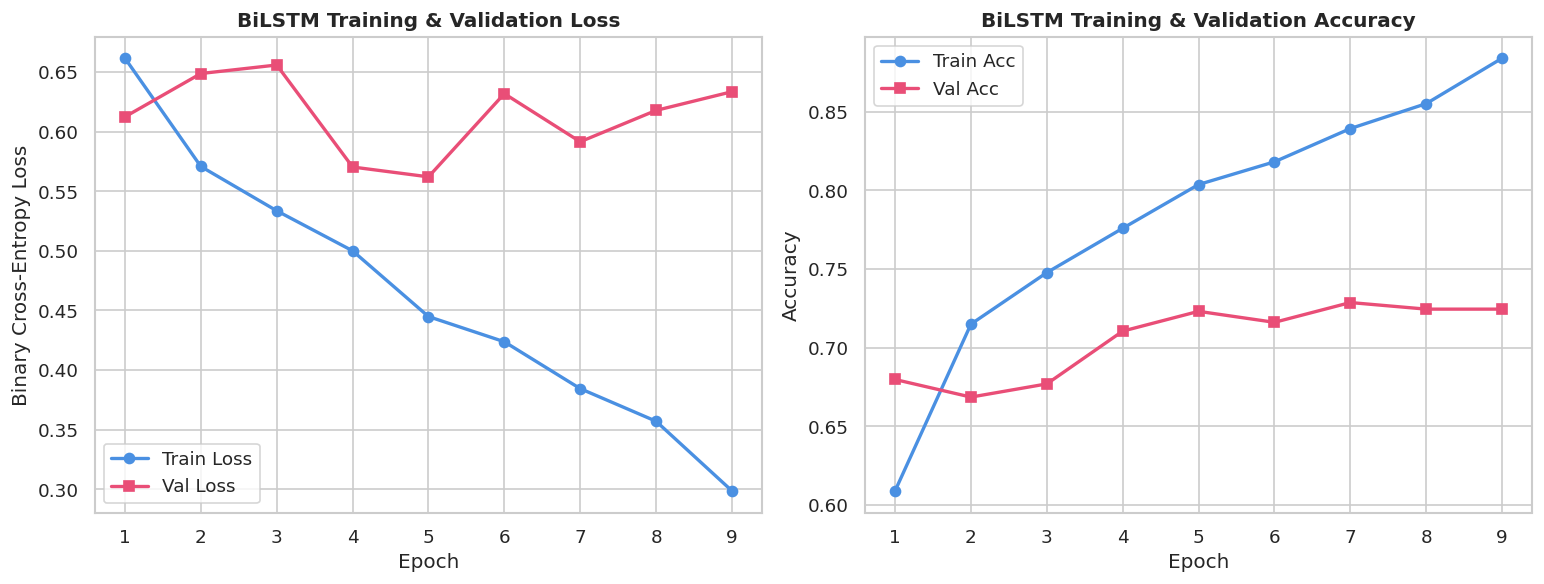

In [6]:
epochs_range = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(epochs_range, history["train_loss"], "o-", label="Train Loss", color="#4A90E2", lw=2)
axes[0].plot(epochs_range, history["val_loss"], "s-", label="Val Loss", color="#E94E77", lw=2)
axes[0].set_title("BiLSTM Training & Validation Loss", fontsize=12, weight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Cross-Entropy Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], "o-", label="Train Acc", color="#4A90E2", lw=2)
axes[1].plot(epochs_range, history["val_acc"], "s-", label="Val Acc", color="#E94E77", lw=2)
axes[1].set_title("BiLSTM Training & Validation Accuracy", fontsize=12, weight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "bilstm_training_curves.png", dpi=300)
plt.show()

---  
## 6. Clinical Decision Threshold Tuning (Target Recall $\ge 80\%$)

In [7]:
# Compute validation probabilities
model.eval()
val_probs, val_labels = [], []
with torch.no_grad():
    for batch in val_loader:
        x, y = batch["input_ids"].to(device), batch["label"].to(device)
        logits = model(x)
        val_probs.extend(torch.sigmoid(logits).cpu().numpy())
        val_labels.extend(y.cpu().numpy().astype(int))

y_probs_bilstm = np.array(val_probs)
y_true = np.array(val_labels)

# Search threshold
thresholds = np.linspace(0.05, 0.95, 91)
candidates = []
fallback_best_f1, fallback_thresh = -1.0, 0.5

for t in thresholds:
    preds = (y_probs_bilstm >= t).astype(int)
    rec = recall_score(y_true, preds, zero_division=0)
    prec = precision_score(y_true, preds, zero_division=0)
    f1 = f1_score(y_true, preds, zero_division=0)

    if rec >= 0.80 and prec >= 0.50:
        candidates.append({"threshold": float(t), "recall": float(rec), "precision": float(prec), "f1": float(f1)})
    if prec >= 0.50 and f1 > fallback_best_f1:
        fallback_best_f1, fallback_thresh = f1, float(t)

if candidates:
    candidates.sort(key=lambda x: (x["f1"], x["precision"]), reverse=True)
    best_thresh_bilstm = round(candidates[0]["threshold"], 4)
else:
    best_thresh_bilstm = round(float(fallback_thresh), 4)

y_preds_tuned = (y_probs_bilstm >= best_thresh_bilstm).astype(int)

print(f"Calibrated Optimal Threshold: {best_thresh_bilstm:.4f}")
print(f"Validation Recall:            {recall_score(y_true, y_preds_tuned):.4f}")
print(f"Validation Precision:         {precision_score(y_true, y_preds_tuned):.4f}")
print(f"Validation F1-Score:          {f1_score(y_true, y_preds_tuned):.4f}")
print(f"Validation ROC-AUC:           {roc_auc_score(y_true, y_probs_bilstm):.4f}")

Calibrated Optimal Threshold: 0.3600
Validation Recall:            0.8184
Validation Precision:         0.7123
Validation F1-Score:          0.7617
Validation ROC-AUC:           0.8137


---  
## 7. Multi-Model Benchmark Comparison (LR vs SVM vs BiLSTM)
Compare sequential BiLSTM performance directly with classical baselines.

In [8]:
# Load baseline metrics
baseline_metrics_path = MODELS_DIR / "baseline_evaluation_metrics.json"
if baseline_metrics_path.exists():
    with open(baseline_metrics_path, "r", encoding="utf-8") as f:
        bm = json.load(f)
    lr_m = bm.get("logistic_regression", {})
    svm_m = bm.get("svm_model", {})
else:
    lr_m = {"optimal_threshold": 0.39, "accuracy": 0.7552, "precision": 0.7366, "recall": 0.8184, "f1_score": 0.7754, "roc_auc": 0.8399}
    svm_m = {"optimal_threshold": 0.39, "accuracy": 0.7524, "precision": 0.7017, "recall": 0.9051, "f1_score": 0.7905, "roc_auc": 0.8293}

cm_bilstm = confusion_matrix(y_true, y_preds_tuned)

comparison_df = pd.DataFrame([
    {
        "Architecture": "Logistic Regression + TF-IDF (Tuned)",
        "Threshold (\u03c4)": f"{lr_m.get('optimal_threshold', 0.39):.2f}",
        "Accuracy": f"{lr_m.get('accuracy', 0):.4f}",
        "Precision": f"{lr_m.get('precision', 0):.4f}",
        "Recall (Primary)": f"{lr_m.get('recall', 0):.4f}",
        "F1-Score": f"{lr_m.get('f1_score', 0):.4f}",
        "ROC-AUC": f"{lr_m.get('roc_auc', 0):.4f}",
    },
    {
        "Architecture": "Support Vector Machine RBF (Tuned)",
        "Threshold (\u03c4)": f"{svm_m.get('optimal_threshold', 0.39):.2f}",
        "Accuracy": f"{svm_m.get('accuracy', 0):.4f}",
        "Precision": f"{svm_m.get('precision', 0):.4f}",
        "Recall (Primary)": f"{svm_m.get('recall', 0):.4f}",
        "F1-Score": f"{svm_m.get('f1_score', 0):.4f}",
        "ROC-AUC": f"{svm_m.get('roc_auc', 0):.4f}",
    },
    {
        "Architecture": "BiLSTM + Self-Attention (Tuned)",
        "Threshold (\u03c4)": f"{best_thresh_bilstm:.2f}",
        "Accuracy": f"{accuracy_score(y_true, y_preds_tuned):.4f}",
        "Precision": f"{precision_score(y_true, y_preds_tuned):.4f}",
        "Recall (Primary)": f"{recall_score(y_true, y_preds_tuned):.4f}",
        "F1-Score": f"{f1_score(y_true, y_preds_tuned):.4f}",
        "ROC-AUC": f"{roc_auc_score(y_true, y_probs_bilstm):.4f}",
    },
])

display(comparison_df)

,Architecture,Threshold (τ),Accuracy,Precision,Recall (Primary),F1-Score,ROC-AUC
0,Logistic Regression + TF-IDF (Tuned),0.39,0.7552,0.7366,0.8184,0.7754,0.8399
1,Support Vector Machine RBF (Tuned),0.39,0.7524,0.7017,0.9051,0.7905,0.8293
2,BiLSTM + Self-Attention (Tuned),0.36,0.7357,0.7123,0.8184,0.7617,0.8137


---  
## 8. Export Model Checkpoint & Pipeline

In [9]:
# Save model weights & architecture configuration
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "config": {
            "vocab_size": tokenizer.vocab_size,
            "embedding_dim": 128,
            "hidden_dim": 128,
            "num_layers": 2,
            "dropout": 0.35,
            "max_seq_len": 160,
        },
    },
    MODELS_DIR / "bilstm_model.pt",
)
joblib.dump(best_thresh_bilstm, MODELS_DIR / "threshold_bilstm.pkl")

print("Phase 3 BiLSTM Deep Sequential Modeling completed and serialized successfully!")

Phase 3 BiLSTM Deep Sequential Modeling completed and serialized successfully!
